In [2]:
import pandas as pd
import numpy as np
from plotnine import *
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

## Section 01 - Visualizing multiple variables
In this exercise, we will revisit how to do a correlation analysis and potential pitfalls of correlation
analysis. We will use the gene expression data in cancer_data.txt which stores the expression of 20
genes across 30 different tumor samples. Gene expression measures the abundance of RNAs per gene
and is indicative of how active a gene is in a sample. If the expression of a gene differs a lot between
conditions (e.g. healthy versus cancer or different cancer types) it could hint that this gene plays an
important role in this context.
Load the gene expression data in cancer_data.txt as a pd.DataFrame with the following line of code:
`` expr = pd.read_csv("../../extdata/cancer_data.txt", sep="\t", index_col=0) ``
1. We are interested in the correlations between genes. Plot the pairwise correlations of the variables in
the dataset. Which pair of genes has the highest correlation? Hint: you can use the correlation method
pd.DataFrame.corr() and the plotting function sns.clustermap.
2. Visualize the raw data in a heatmap with sns.clustermap.
3. Does the latter plot suggest some outliers? Could they have affected the correlations? Check by using
an appropriate plot the impact of these outliers on the correlations in question 1. Substitute them with
missing values (NA) and redo the previous questions 1 and 2.

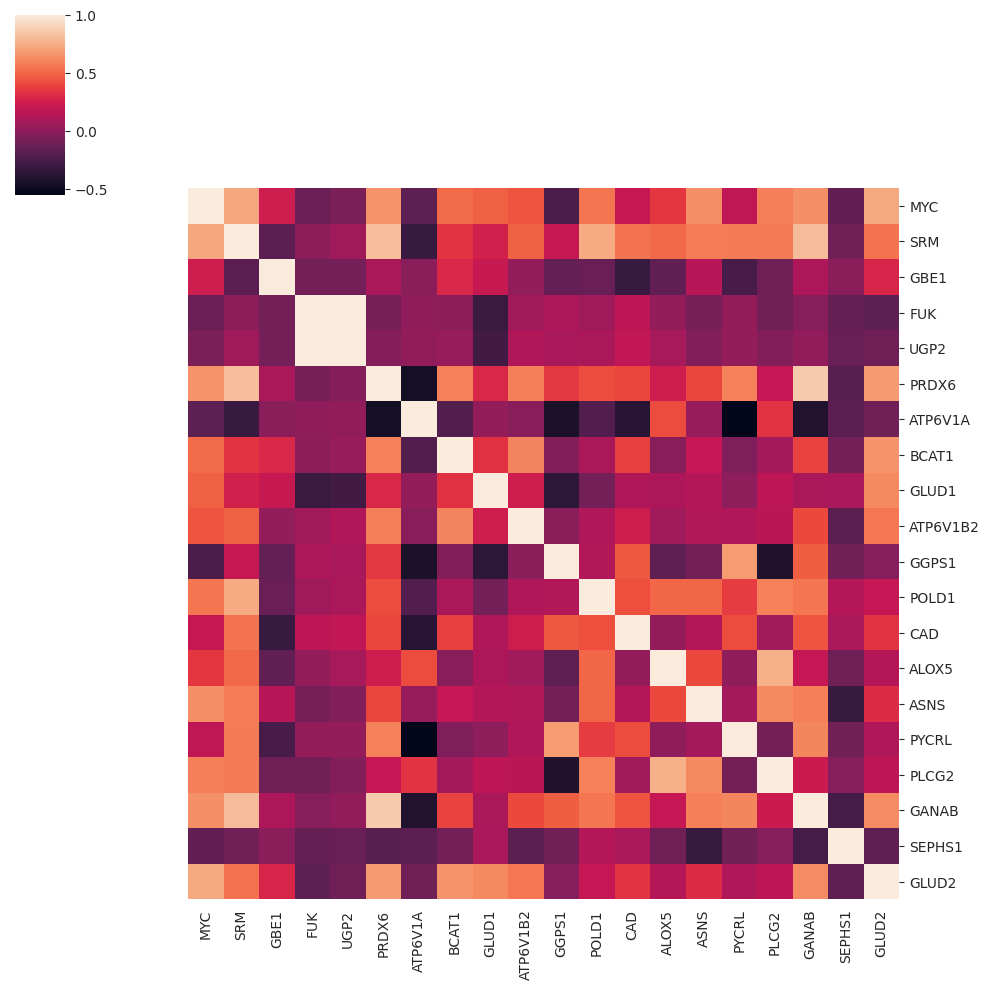

In [20]:
cancer_data = pd.read_csv("cancer_data.txt", sep="\t", index_col=0)
sns.clustermap(cancer_data.corr(), row_cluster=False, col_cluster=False)


## Section 02 - Heatmaps and Hierarchical Clustering
1. Consider the full iris data set without the Species column for clustering. Create a pretty heatmap
with the library sns.clustermap of the data without clustering.
2. Now, create a pretty heatmap using complete linkage clustering of the rows of the data set. Hint:
You can specify a clustering method with the method argument in sns.clustermap
3. Compute the row clustering using complete linkage clustering and partition the data into 3 clusters.
Hint: You can use sklearn.cluster.AgglomerativeClustering().
4. Annotate the rows of the heatmap with the Species column of the iris dataset and the three clusters
from complete linkage clustering. What do you observe when you compare the clustering and the species
labels?

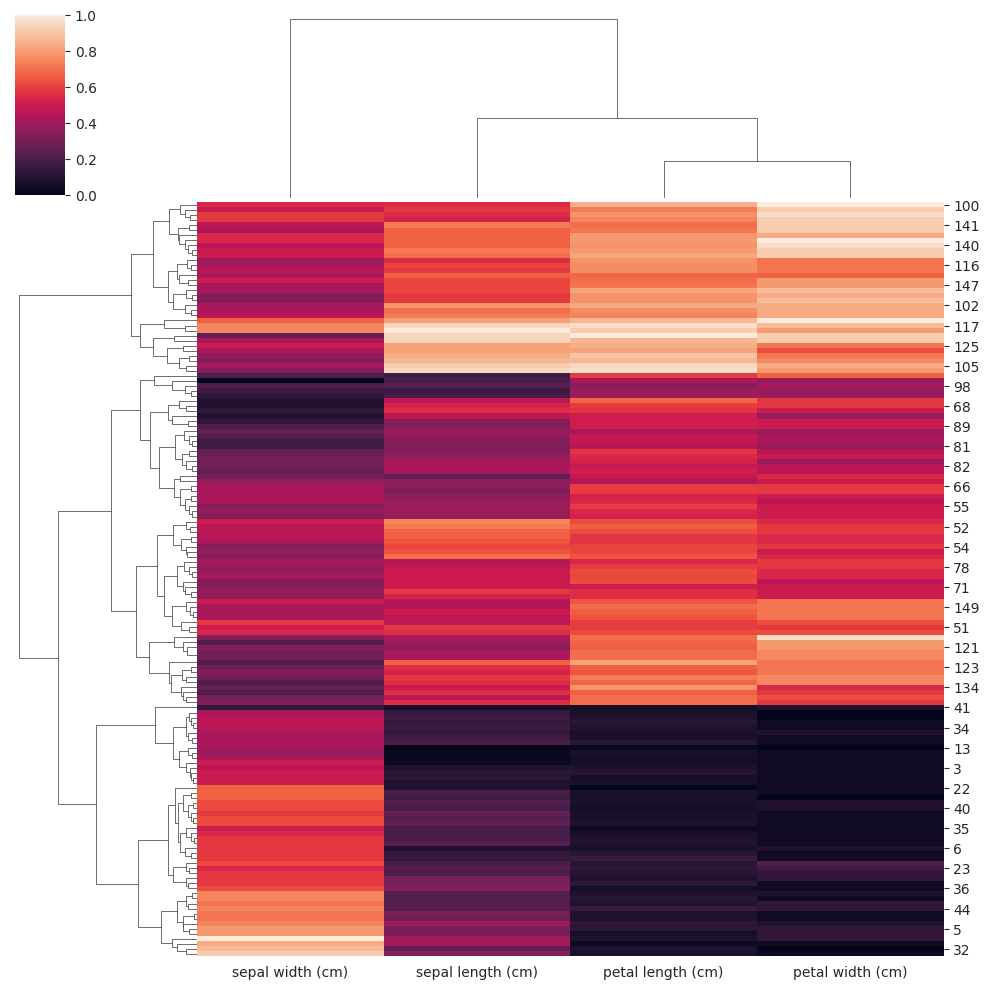

In [48]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame=True)
iris_df = iris['frame']
iris_df['target'] = ['setosa' if s==0 else 'versicolor' if s==1 else 'virginica' \
                  for s in iris['target']]
numeric_df = iris_df.drop(columns=['target'])   # drop target for heatmap

iris_df.head()
sns.clustermap(
    numeric_df,
    standard_scale=1,
    row_cluster=True,
    col_cluster=True,
    method='complete' # complete linkage
) # 1.

x_iris = sklearn.preprocessing.StandardScaler().fit_transform(numeric_df. iloc[:,:-1])
hc = sklearn.cluster.AgglomerativeClustering(n_clusters=3, linkage='complete').fit(x_iris) # 2.
